In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from unsflow.utils.thesis_plots import *

In [7]:

input_filenames = [
        "../02_Convert_To_CTBFM/Output/grid_35x25_0.csv",
        "../02_Convert_To_CTBFM/Output/grid_69x49_0.csv",
        "../02_Convert_To_CTBFM/Output/grid_137x97_0.csv",
        "../02_Convert_To_CTBFM/Output/grid_273x193_0.csv",
        ]

labels = [
        '35x25',
        '69x49',
        '137x97',
        '273x193',
]

In [8]:
datas = {}

for ii,input_filename in enumerate(input_filenames):
    with open(input_filename, 'r') as f:
            ndims = int(f.readline().strip().split('=')[1])
            ni = int(f.readline().strip().split('=')[1])
            nj = int(f.readline().strip().split('=')[1])
            nk = int(f.readline().strip().split('=')[1])
        
    df = pd.read_csv(input_filename, skiprows=4)
    data = {col: df[col].to_numpy().reshape((ni, nj, nk)) for col in df.columns}
    datas[ii] = data

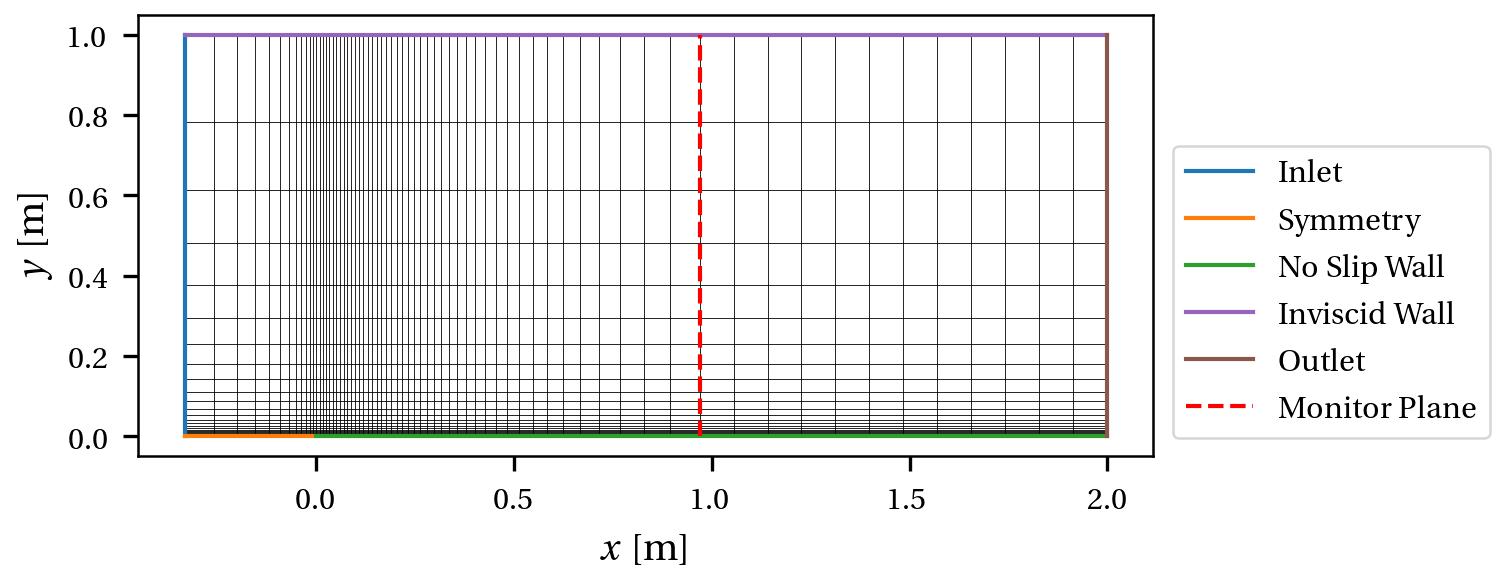

In [9]:
set_thesis_style()
fig, ax = create_figure(fraction=1, aspect_ratio=2.6, subplots=(1, 1))
xComparison = 0.97

data = datas[1]
ni,nj,nk = data['x'].shape
for i in range(1, ni-1):
    ax.plot(data['x'][i, :, 0], data['y'][i, :, 0], 'k', lw=0.2)
for j in range(1, nj-1):
    ax.plot(data['x'][:, j, 0], data['y'][:, j, 0], 'k', lw=0.2)

iIdx = np.argmin(np.abs(data['x'][:, 0, 0])-0)

ax.plot(data['x'][0, :, 0], data['y'][0, :, 0], 'C0', label='Inlet')
ax.plot(data['x'][0:iIdx, 0, 0], data['y'][0:iIdx, 0, 0], 'C1', label='Symmetry')
ax.plot(data['x'][iIdx:, 0, 0], data['y'][iIdx:, 0, 0], 'C2', label='No Slip Wall')
ax.plot(data['x'][:, -1, 0], data['y'][:, -1, 0], 'C4', label='Inviscid Wall')
ax.plot(data['x'][-1, :, 0], data['y'][-1, :, 0], 'C5', label='Outlet')
iCheck = np.argmin(np.abs(data['x'][:, 0, 0]-xComparison))
ax.plot(data['x'][iCheck, :, 0], data['y'][-1, :, 0], '--r', label='Monitor Plane')


ax.set_xlabel(r'$x~\rm{[m]}$')
ax.set_ylabel(r'$y~\rm{[m]}$')


fig.legend(ncol=1, loc='outside right')
fig.savefig('turbulent_flatplate_69x49.pdf')